# Baseline Model



In [15]:
# imports
import io
from pathlib import Path

import joblib
import librosa
import matplotlib.pyplot as plt
import numpy as np
import soundfile as sf
import torch
import torch.nn.functional as F
import torchaudio
from datasets import Audio, load_dataset, load_dataset_builder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, log_loss, precision_recall_fscore_support
from sklearn.model_selection import train_test_split

## Configuration

In [16]:
# audio processing parameters
SAMPLE_RATE = 22050
CLIP_DURATION = 5
CLIP_SAMPLES = SAMPLE_RATE * CLIP_DURATION
N_MFCC = 13

# dataset sampling
SAMPLES_PER_CLASS = 500
DATASET_SAMPLE_COUNT = None  # set to an int to use a smaller shuffled subset

RANDOM_SEED = 42
TRAINING_EPOCHS = 30

# performance settings
FEATURE_CACHE = True
FEATURE_CACHE_DIR = Path("data/feature_cache")
FEATURE_CACHE_DIR.mkdir(parents=True, exist_ok=True)

In [17]:
# login Hugging Face Hub
import os
from dotenv import load_dotenv

load_dotenv()  
HF_TOKEN = os.getenv("HF_TOKEN")

from huggingface_hub import login

login(token=HF_TOKEN) 

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


In [18]:
# inspect dataset
ds_builder = load_dataset_builder("SleepyJesse/ai_music_tiny")
ds_builder.info.description
ds_builder.info.features

{'audio': Audio(sampling_rate=None, decode=True, num_channels=None, stream_index=None),
 'ai_generated': Value('bool'),
 'source': Value('string')}

In [19]:
# load dataset
# ds = load_dataset("SleepyJesse/ai_music_tiny", split="train", cache_dir="./data")
ds = load_dataset("SleepyJesse/ai_music_tiny", split="train")
# Avoid torchcodec decoding in environments where FFmpeg/TorchCodec isn't configured.
ds = ds.cast_column("audio", Audio(decode=False))

if DATASET_SAMPLE_COUNT is not None:
    sample_count = min(DATASET_SAMPLE_COUNT, len(ds))
    ds = ds.shuffle(seed=RANDOM_SEED).select(range(sample_count))
    print(f"Using {sample_count} sampled examples from the dataset.")

ds

Dataset({
    features: ['audio', 'ai_generated', 'source'],
    num_rows: 1000
})

Sampling and data processing

In [20]:
def _resolve_label_key(example, preferred=None):
    if preferred is not None and preferred in example:
        return preferred

    for candidate in ("ai_generated", "label", "target", "class"):
        if candidate in example:
            return candidate

    raise KeyError(
        f"Could not find a label column. Available keys: {list(example.keys())}"
    )


def sample_per_class(dataset, label_key=None, samples_per_class=500):
    class_counts = {}
    selected_indices = []
    expected_labels = None

    if hasattr(dataset, "features") and label_key is None:
        if "ai_generated" in dataset.features:
            label_key = "ai_generated"
        elif "label" in dataset.features:
            label_key = "label"

    if hasattr(dataset, "features") and label_key in getattr(dataset, "features", {}):
        label_feature = dataset.features[label_key]
        if hasattr(label_feature, "names") and label_feature.names is not None:
            expected_labels = set(range(len(label_feature.names)))
        elif getattr(label_feature, "dtype", None) == "bool":
            expected_labels = {False, True}

    # For Hugging Face Dataset objects, iterate over label column only to avoid audio decoding.
    if hasattr(dataset, "num_rows") and hasattr(dataset, "select"):
        if label_key is None:
            first_example = dataset[0]
            label_key = _resolve_label_key(first_example)

        labels = dataset[label_key]
        for idx, label in enumerate(labels):
            if label not in class_counts:
                class_counts[label] = 0

            if class_counts[label] < samples_per_class:
                selected_indices.append(idx)
                class_counts[label] += 1

            if expected_labels is not None and all(
                class_counts.get(lbl, 0) >= samples_per_class for lbl in expected_labels
            ):
                break

        return dataset.select(selected_indices)

    for example in dataset:
        label_key = _resolve_label_key(example, preferred=label_key)
        label = example[label_key]

        if label not in class_counts:
            class_counts[label] = 0

        if class_counts[label] < samples_per_class:
            selected_indices.append(example)
            class_counts[label] += 1

        if expected_labels is not None and all(
            class_counts.get(lbl, 0) >= samples_per_class for lbl in expected_labels
        ):
            break

    return selected_indices

In [21]:
def resample_audio(waveform, original_sr):
    if original_sr != SAMPLE_RATE:
        resampler = torchaudio.transforms.Resample(original_sr, SAMPLE_RATE)
        waveform = resampler(waveform)
    return waveform


def pad_or_trim_audio(waveform):
    total_samples = waveform.shape[1]

    if total_samples < CLIP_SAMPLES:
        padding = CLIP_SAMPLES - total_samples
        waveform = F.pad(waveform, (0, padding))
    elif total_samples > CLIP_SAMPLES:
        waveform = waveform[:, :CLIP_SAMPLES]

    return waveform


def segment_audio(waveform):
    segments = []
    total_samples = waveform.shape[1]

    if total_samples < CLIP_SAMPLES:
        return segments

    for start in range(0, total_samples - CLIP_SAMPLES + 1, CLIP_SAMPLES):
        end = start + CLIP_SAMPLES
        segment = waveform[:, start:end]

        if segment.shape[1] == CLIP_SAMPLES:
            segments.append(segment)

    return segments


def select_single_segment(waveform):
    segments = segment_audio(waveform)
    if segments:
        return segments[0]
    return pad_or_trim_audio(waveform)

Extract mel frequency cepstral coefficients

In [22]:
def extract_mfcc_features(audio, sr=SAMPLE_RATE, n_mfcc=N_MFCC):
    mfcc = librosa.feature.mfcc(
        y=np.asarray(audio, dtype=np.float32),
        sr=sr,
        n_mfcc=n_mfcc
    )

    mfcc_mean = mfcc.mean(axis=1)
    mfcc_std = mfcc.std(axis=1)

    return np.concatenate([mfcc_mean, mfcc_std]).astype(np.float32)

Build dataset

In [23]:
def _read_audio_clip(source):
    with sf.SoundFile(source) as audio_file:
        samples = audio_file.read(frames=-1, dtype="float32", always_2d=True)
        source_sr = audio_file.samplerate

    waveform = torch.from_numpy(samples.T)
    return waveform, source_sr


def _load_waveform(audio):
    if audio.get("array") is not None:
        waveform = torch.tensor(audio["array"], dtype=torch.float32)
        sr = audio["sampling_rate"]
    else:
        audio_bytes = audio.get("bytes")
        audio_path = audio.get("path")

        if audio_bytes:
            waveform, sr = _read_audio_clip(io.BytesIO(audio_bytes))
        elif audio_path:
            waveform, sr = _read_audio_clip(audio_path)
        else:
            raise ValueError("Audio sample is missing both decoded data and a readable source.")

    if waveform.dim() == 1:
        waveform = waveform.unsqueeze(0)

    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0, keepdim=True)

    return waveform, sr


def _feature_cache_path(dataset_subset, label_key=None):
    subset_size = len(dataset_subset)
    resolved_label_key = label_key or "auto"
    return FEATURE_CACHE_DIR / (
        f"baseline_mfcc_{subset_size}_{resolved_label_key}_{SAMPLE_RATE}sr_"
        f"{CLIP_DURATION}s_{N_MFCC}mfcc.joblib"
    )


def build_feature_dataset(dataset_subset, label_key=None, cache_features=FEATURE_CACHE):
    cache_path = _feature_cache_path(dataset_subset, label_key)

    if cache_features and cache_path.exists():
        cached = joblib.load(cache_path)
        return cached["X"], cached["y"]

    X = []
    y = []

    for example in dataset_subset:
        resolved_label_key = _resolve_label_key(example, preferred=label_key)
        label = example[resolved_label_key]

        if "audio" not in example:
            raise KeyError("Expected an 'audio' column in the dataset.")

        waveform, sr = _load_waveform(example["audio"])
        waveform = resample_audio(waveform, sr)
        waveform = select_single_segment(waveform)
        features = extract_mfcc_features(waveform.squeeze(0).cpu().numpy())

        X.append(features)
        y.append(label)

    X = np.asarray(X, dtype=np.float32)
    y = np.asarray(y)

    if cache_features:
        joblib.dump({"X": X, "y": y}, cache_path)

    return X, y

Train model

In [24]:
subset = sample_per_class(ds, label_key="ai_generated", samples_per_class=SAMPLES_PER_CLASS)
print("Subset size:", len(subset))

Subset size: 1000


In [25]:
X, y = build_feature_dataset(subset, label_key="ai_generated")

print("Feature shape:", X.shape)

Feature shape: (1000, 26)


In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_SEED
)

# Train incrementally so we can record loss after each solver pass.
model = LogisticRegression(
    max_iter=1,
    warm_start=True,
    solver="saga",
    random_state=RANDOM_SEED
)

train_losses = []
for epoch in range(TRAINING_EPOCHS):
    model.fit(X_train, y_train)
    y_train_proba = model.predict_proba(X_train)
    train_loss = log_loss(y_train, y_train_proba, labels=model.classes_)
    train_losses.append(train_loss)

y_pred = model.predict(X_test)

C:\Users\lilyc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\lilyc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\lilyc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\lilyc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_sag.py:348: Conve

In [27]:
def plot_baseline_metrics(y_true, y_pred, class_names=("Human", "AI-generated")):
    cm = confusion_matrix(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average=None,
        labels=[0, 1],
        zero_division=0
    )

    metrics = np.vstack([precision, recall, f1])
    metric_names = ["Precision", "Recall", "F1-score"]
    x = np.arange(len(class_names))
    width = 0.25

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    im = ax1.imshow(cm, cmap="Blues")
    ax1.set_title("Confusion Matrix")
    ax1.set_xlabel("Predicted label")
    ax1.set_ylabel("True label")
    ax1.set_xticks([0, 1], class_names)
    ax1.set_yticks([0, 1], class_names)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax1.text(j, i, str(cm[i, j]), ha="center", va="center", color="black")

    fig.colorbar(im, ax=ax1, fraction=0.046, pad=0.04)

    for idx, name in enumerate(metric_names):
        ax2.bar(x + (idx - 1) * width, metrics[idx], width=width, label=name)

    ax2.set_title("Per-class Metrics")
    ax2.set_xlabel("Class")
    ax2.set_ylabel("Score")
    ax2.set_xticks(x, class_names)
    ax2.set_ylim(0, 1.05)
    ax2.legend()

    plt.tight_layout()
    plt.show()


def plot_training_loss(train_losses):
    epochs = np.arange(1, len(train_losses) + 1)
    plt.figure(figsize=(7, 4))
    plt.plot(epochs, train_losses, marker="o")
    plt.title("Training Loss Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Log Loss")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

Accuracy: 0.67
              precision    recall  f1-score   support

       False       0.66      0.71      0.68       100
        True       0.68      0.63      0.66       100

    accuracy                           0.67       200
   macro avg       0.67      0.67      0.67       200
weighted avg       0.67      0.67      0.67       200



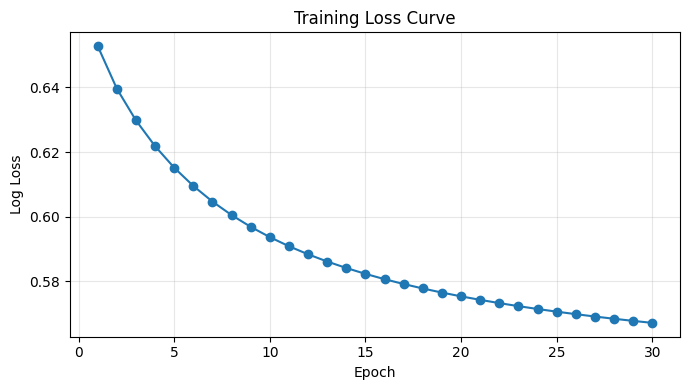

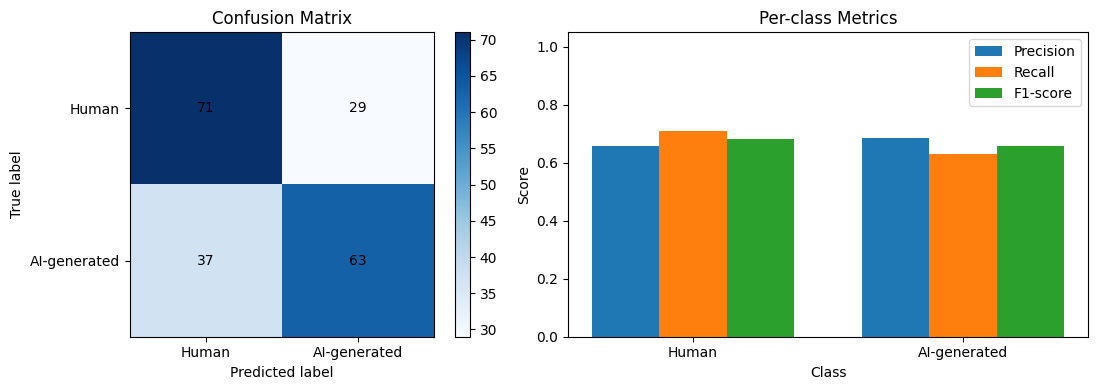

In [28]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

plot_training_loss(train_losses)
plot_baseline_metrics(y_test, y_pred)

In [29]:
# save model with joblib
Path("models").mkdir(parents=True, exist_ok=True)
joblib.dump(model, "models/logistic_regression_model.joblib")

['models/logistic_regression_model.joblib']

In [30]:
# test loaded model
test = joblib.load("models/logistic_regression_model.joblib")
test.predict(X_test[:5])

array([ True, False, False, False,  True])